# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [87]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_macro_stream_22.h5ad"
binarized_file_output = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/data_binarized_stream_22.csv"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint

In [20]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
import json
import requests
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde
import math
import time
#! pip install goatools
#!pip install leidenalg

In [88]:
warnings.filterwarnings("ignore")
adata = sc.read(input_file) # read data 
if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

=== This dataset is now normalised
=== Cell type and macrostates in our dataset
['B naive', 'B intermediate', 'B', 'B memory', 'Bridge']
Categories (5, object): ['B', 'B intermediate', 'B memory', 'B naive', 'Bridge']
['None', 'S2', 'S20', 'S19', 'S21', 'S12', 'S6']
Categories (7, object): ['None', 'S2', 'S6', 'S12', 'S19', 'S20', 'S21']


In [41]:
print(adata.obs["macrostates"].unique())
adata.obs["macrostates"] = adata.obs["macrostates"].astype("category")
print(adata.obs["macrostates"].unique())


['None', 'S2', 'S20', 'S19', 'S12']
Categories (7, object): ['None', 'S2', 'S6', 'S12', 'S19', 'S20', 'S21']
['None', 'S2', 'S20', 'S19', 'S12']
Categories (7, object): ['None', 'S2', 'S6', 'S12', 'S19', 'S20', 'S21']


In [97]:
adata = adata[adata.obs["macrostates"] != "S20"].copy()

In [77]:
print(adata.obs["macrostates"].unique())

['None', 'S2', 'S20', 'S19', 'S12']
Categories (5, object): ['None', 'S2', 'S12', 'S19', 'S20']


# 1) Binarization with DEG

In [93]:
# 1. DEG
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()

sc.tl.rank_genes_groups(
    adata_no_none,
    groupby="macrostates",
    method="wilcoxon",
    reference="rest"
)

deg_res = adata_no_none.uns["rank_genes_groups"]

groups = deg_res["names"].dtype.names
genes = adata_no_none.var_names

records = []
for g in groups:
    df = sc.get.rank_genes_groups_df(
        adata_no_none,
        group=g,
        key="rank_genes_groups"
    )
    df["macrostate"] = g
    records.append(df)

deg_df = pd.concat(records, ignore_index=True)

# Binarisation
deg_df["binary"] = np.where(
    deg_df["logfoldchanges"] > 0.5, 1,
    np.where(deg_df["logfoldchanges"] < -0.5, 0, np.nan)
)

binary_matrix = deg_df.pivot_table(
    index="macrostate",
    columns="names",
    values="binary",
    aggfunc="first"
)
binary_matrix = binary_matrix.dropna(axis=1, how="all")

print(f"NaN : {binary_matrix.isna().sum().sum()}")
print(f"Shape : {binary_matrix.shape}")
percent_nan_total = (binary_matrix.isna().sum().sum() * 100) / binary_matrix.size
print(f"percent Nan : {percent_nan_total}")
binary_matrix

NaN : 28829
Shape : (6, 16787)
percent Nan : 28.62234665713548


names,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
macrostate,,,,,,,,,,,,,,,,,,,,,
None,NaN,1.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,1.0,...,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN
S12,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0,0.0
S19,1.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
S2,NaN,0.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0,NaN
S21,NaN,0.0,1.0,1.0,0.0,1.0,0.0,NaN,NaN,0.0,...,NaN,NaN,0.0,1.0,0.0,NaN,0.0,0.0,NaN,0.0
S6,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0


In [52]:
binary_matrix = binary_matrix.dropna(axis=1, how="all")

print(f"NaN : {binary_matrix.isna().sum().sum()}")
print(f"Shape : {binary_matrix.shape}")
percent_nan_total = (binary_matrix.isna().sum().sum() * 100) / binary_matrix.size
print(f"percent Nan : {percent_nan_total}")
binary_matrix

NaN : 17758
Shape : (6, 14421)
percent Nan : 20.52331091232693


names,A1BG,A2M,A2ML1,A3GALT2,A4GALT,AAAS,AACS,AAGAB,AAK1,AAMDC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
macrostate,,,,,,,,,,,,,,,,,,,,,
S12,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
S19,1.0,NaN,0.0,0.0,0.0,NaN,1.0,1.0,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0
S2,NaN,NaN,1.0,0.0,0.0,NaN,NaN,1.0,NaN,0.0,...,NaN,NaN,1.0,NaN,1.0,0.0,1.0,NaN,1.0,NaN
S20,NaN,1.0,0.0,1.0,0.0,1.0,NaN,1.0,1.0,1.0,...,1.0,NaN,0.0,1.0,NaN,1.0,0.0,1.0,0.0,1.0
S21,NaN,NaN,1.0,0.0,1.0,NaN,0.0,0.0,0.0,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0
S6,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
genes = ["NANOG", "CEBPA","CEBPB","CEBPD","SPI1","ETV6","BACH2"]
[g for g in genes if g in binary_matrix.columns]
#[g for g in genes if g in results_ovr["names"].values]

['NANOG', 'CEBPA', 'CEBPB', 'CEBPD', 'SPI1', 'ETV6', 'BACH2']

# 2) Binarization with scBoolSeq

## Binarization macrostates separately on HVG

Majority vote threshold fixed 

In [98]:
warnings.filterwarnings("ignore")

# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()

macrostates = adata_no_none.obs["macrostates"].unique()

# STEP 1 : HVG on all dataset
n_top = min(2000, adata_no_none.n_vars - 1)
sc.pp.highly_variable_genes(adata_no_none, n_top_genes=n_top)
adata_hvg = adata_no_none[:, adata_no_none.var['highly_variable']].copy()
hvg_dict = adata_no_none.var[adata_no_none.var['highly_variable']].index.tolist()
print(f"{adata_hvg.n_vars} HVGs selected (global)")

# STEP 2 : DataFrame expression
X_full = adata_hvg.X
if not isinstance(X_full, np.ndarray):
    X_full = X_full.toarray()

expr_df_full = pd.DataFrame(
    X_full,
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)
expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
print(f"{expr_df_full.shape[1]} genes after removing all-zero")

# STEP 3 : scBoolSeq
scbool = scBoolSeq(zeroinf_binarizer="quantile", margin_quantile=0.2, dor_threshold=0.85, alpha=0)
scbool.fit(expr_df_full)
binarized = scbool.binarize(expr_df_full)  # cells x genes (0/1/NaN)

macrostate_labels = adata_no_none.obs.loc[binarized.index, "macrostates"]

#  STEP 4-6 : proportions, threshold and vote per macrostates
results = {}
thresholds_per_ct = {}

for ct in macrostates:
    binarized_ct = binarized.loc[macrostate_labels == ct]
    n_cells = binarized_ct.shape[0]
    print(f"\n{'='*50}")
    print(f"{ct}: {n_cells} cells")

    gene_stats = {}
    def majority_vote(col):
        if col.isna().mean() > 0.8:
            return np.nan
        valid = col.dropna()
        if (valid == 0).mean() > 0.4:
            return 0
        elif (valid == 1).mean() > 0.4:
            return 1
        return np.nan
    aggregated = binarized_ct.apply(lambda col: majority_vote(col), axis=0)
    results[ct] = aggregated

    n_ones, n_zeros, n_nan = (aggregated==1).sum(), (aggregated==0).sum(), aggregated.isna().sum()
    total = n_ones + n_zeros + n_nan
    print(f"ON: {n_ones} | OFF: {n_zeros} | NaN: {n_nan}")
    print(f"{n_ones*100/total:.2f}% ON, {n_zeros*100/total:.2f}% OFF, {n_nan*100/total:.2f}% NaN")

# Final dataframe
binarized_states = pd.DataFrame(results).T
binarized_states.index.name = "macrostates"
percent_nan_total = (binarized_states.isna().sum().sum() * 100) / binarized_states.size
print(f"\n{'='*50}")
print(binarized_states.shape)
print(f"{percent_nan_total:.2f} % of NaN in complete dataframe")

2000 HVGs selected (global)
2000 genes after removing all-zero

S2: 199 cells
ON: 315 | OFF: 89 | NaN: 1596
15.75% ON, 4.45% OFF, 79.80% NaN

S19: 199 cells
ON: 403 | OFF: 43 | NaN: 1554
20.15% ON, 2.15% OFF, 77.70% NaN

S21: 200 cells
ON: 285 | OFF: 84 | NaN: 1631
14.25% ON, 4.20% OFF, 81.55% NaN

S12: 200 cells
ON: 147 | OFF: 114 | NaN: 1739
7.35% ON, 5.70% OFF, 86.95% NaN

S6: 198 cells
ON: 132 | OFF: 104 | NaN: 1764
6.60% ON, 5.20% OFF, 88.20% NaN

(5, 2000)
82.84 % of NaN in complete dataframe


Global distribution on 798 cells, 2000 genes


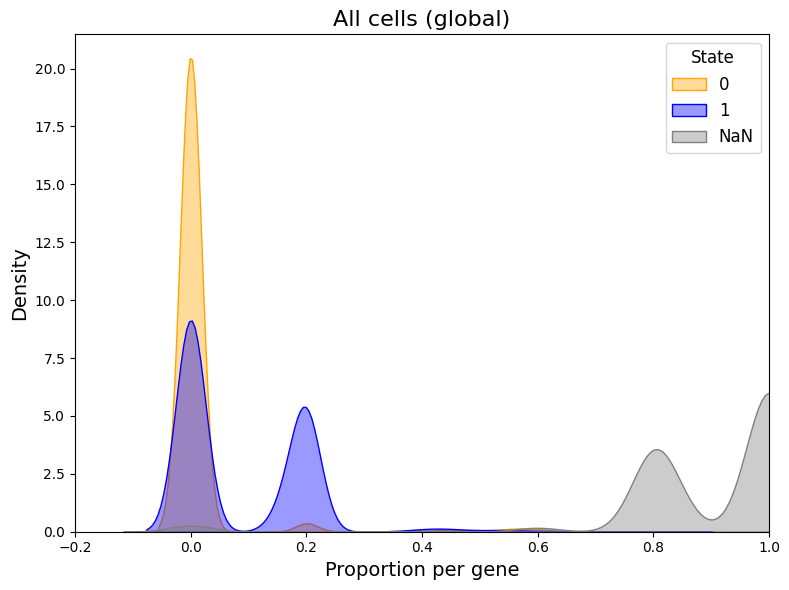

In [79]:
# Global distribution globale
n_cells_total = binarized.shape[0]

gene_stats_global = {}
for gene in binarized.columns:
    col = binarized[gene]
    gene_stats_global[gene] = {
        "prop_1":   (col == 1).mean(),
        "prop_0":   (col == 0).mean(),
        "prop_nan": col.isna().mean()
    }
stats_df_global = pd.DataFrame(gene_stats_global).T

print(f"Global distribution on {n_cells_total} cells, {stats_df_global.shape[0]} genes")

fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(stats_df_global["prop_0"],   fill=True, alpha=0.4, color="orange", label="0",   ax=ax)
sns.kdeplot(stats_df_global["prop_1"],   fill=True, alpha=0.4, color="blue",   label="1",   ax=ax)
sns.kdeplot(stats_df_global["prop_nan"], fill=True, alpha=0.4, color="gray",   label="NaN", ax=ax)

ax.set_title("All cells (global)", fontsize=16)
ax.set_xlim(-0.2, 1)
ax.set_xlabel("Proportion per gene", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.legend(title="State", fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.savefig(
    f"{output_directory}/distribution_scboolseq_global.png",
    dpi=200, bbox_inches="tight"
)
plt.show()

2000 HVGs selected (global)
2000 genes after removing all-zero

S9: 500 cells
Thresholds ON  : [0.086 0.377 0.561 0.652 0.784 0.827 0.899]
Thresholds OFF : [0.079 0.139 0.198 0.347 0.444 0.643 0.738 0.861 0.908 0.971]
Thresholds NaN : [0.262 0.512 0.766 0.916]
ON: 454 | OFF: 123 | NaN: 1423
22.70% ON, 6.15% OFF, 71.15% NaN

S8: 500 cells
Thresholds ON  : [0.092 0.372 0.601 0.74  0.865 0.937]
Thresholds OFF : [0.083 0.157 0.217 0.321 0.387 0.441 0.633 0.718 0.887]
Thresholds NaN : [0.156 0.395 0.464 0.909]
ON: 443 | OFF: 112 | NaN: 1445
22.15% ON, 5.60% OFF, 72.25% NaN

S0: 500 cells
Thresholds ON  : [0.082 0.211 0.371 0.52  0.615 0.732 0.911]
Thresholds OFF : [0.098 0.14  0.187 0.269 0.385 0.479 0.631 0.7   0.758 0.819 0.921]
Thresholds NaN : [0.324 0.912]
ON: 482 | OFF: 101 | NaN: 1417
24.10% ON, 5.05% OFF, 70.85% NaN

S5: 500 cells
Thresholds ON  : [0.046 0.328 0.447 0.527 0.57  0.628 0.668 0.767 0.883 0.95 ]
Thresholds OFF : [0.062 0.133 0.227 0.329 0.372 0.429 0.477 0.556 0.675 0.8

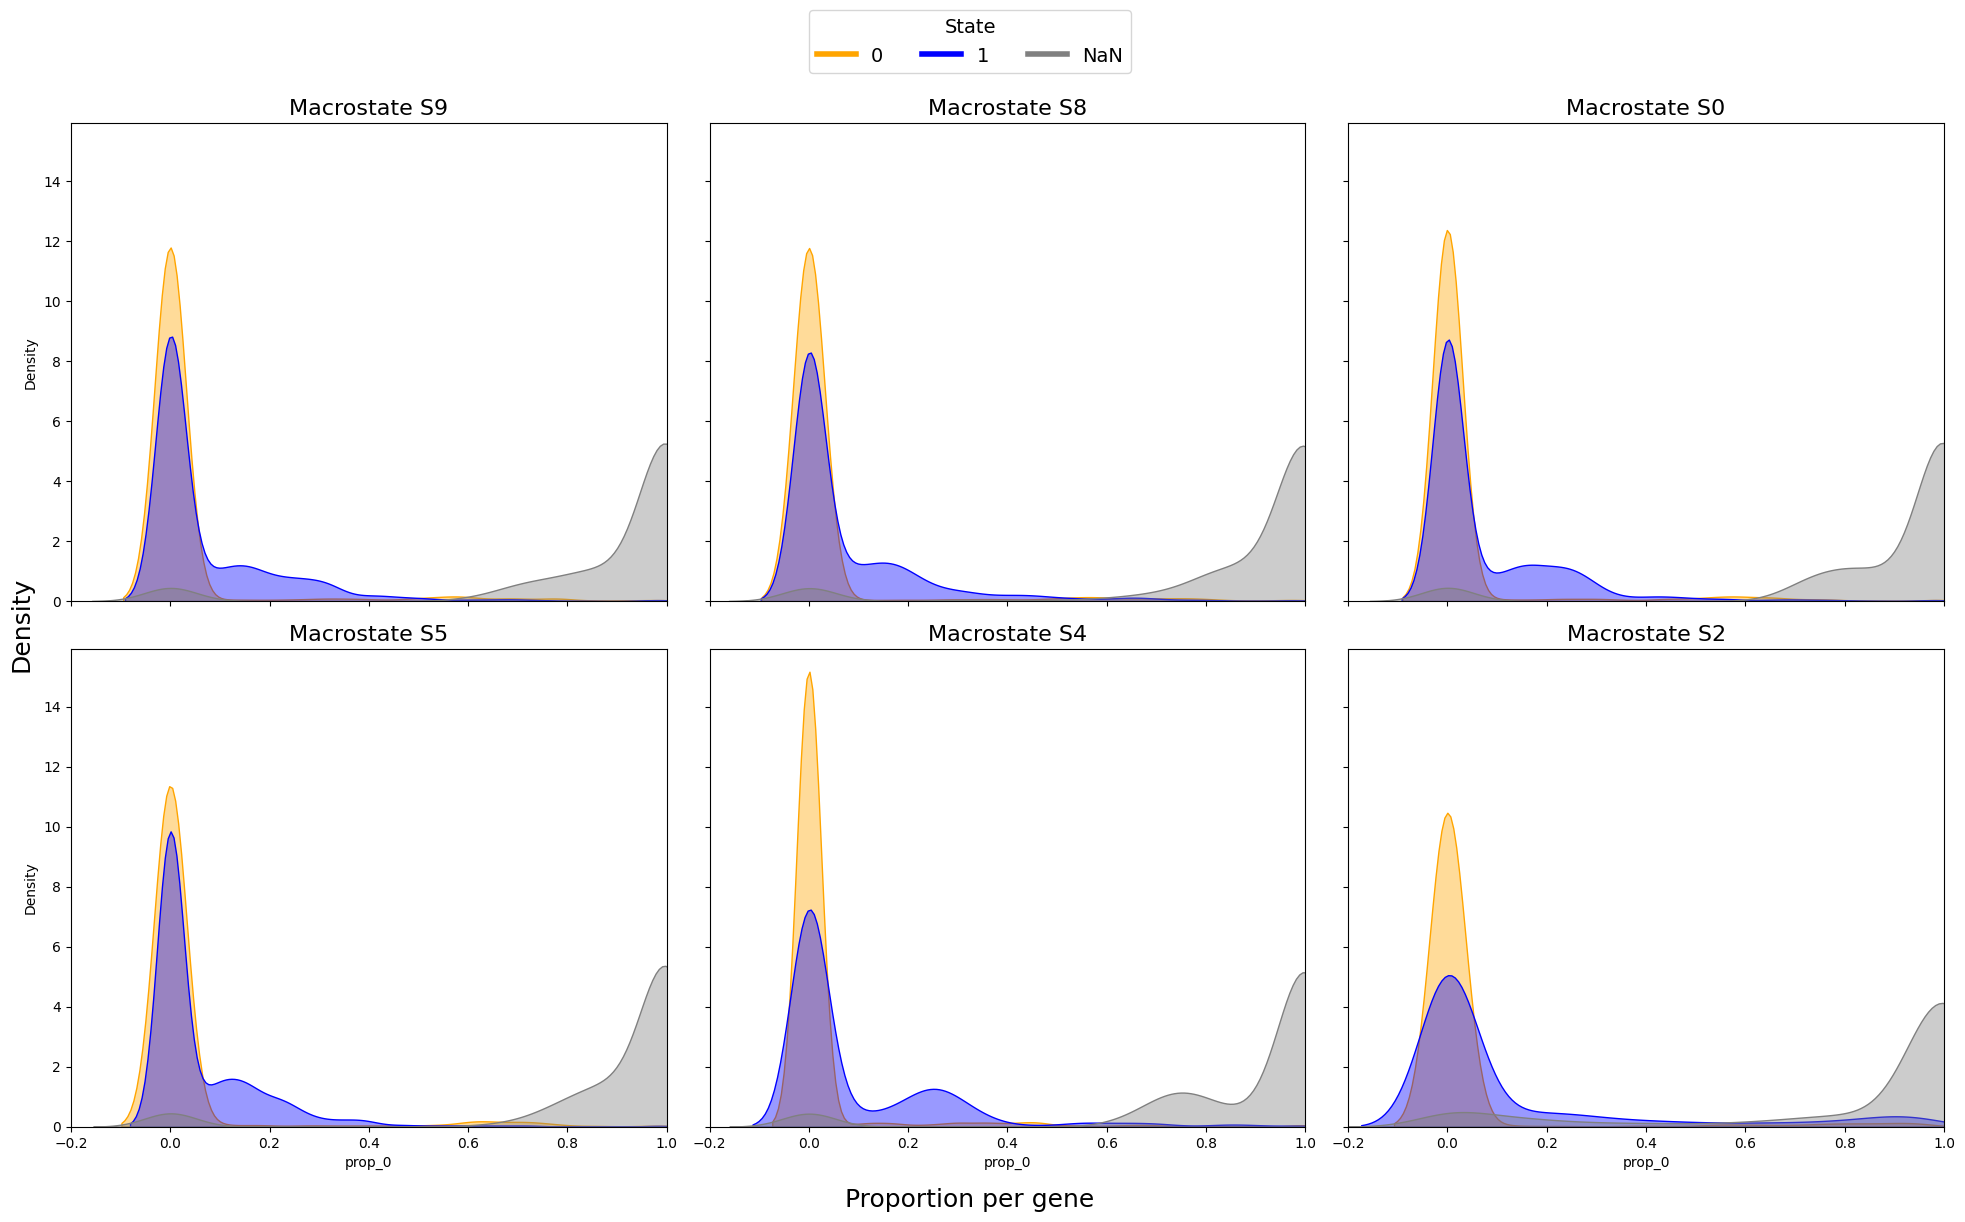

(6, 2000)


In [24]:
warnings.filterwarnings("ignore")

# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()
macrostates = adata_no_none.obs["macrostates"].unique()

def find_valley_thresholds(values, bandwidth=0.1, order=30):
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.array([])
    kde = gaussian_kde(values, bw_method=bandwidth)
    x = np.linspace(values.min(), values.max(), 1000)
    density = kde(x)
    minima_idx = argrelmin(density, order=order)[0]
    return x[minima_idx]

def majority_vote_adaptive(col, t_on, t_off, t_nan):
    prop_nan = col.isna().mean()
    seuil_nan = t_nan[-1] if len(t_nan) > 0 else 0.8
    if prop_nan > seuil_nan:
        return np.nan
    prop_1 = (col == 1).mean()
    prop_0 = (col == 0).mean()
    scale_1 = t_on[1] if len(t_on) > 0 else 0.5
    scale_0 = t_off[1] if len(t_off) > 0 else 0.5
    w1 = prop_1 / (scale_1 + 1e-6)
    w0 = prop_0 / (scale_0 + 1e-6)
    margin = 0.1
    if w1 > w0 + margin:
        return 1
    elif w0 > w1 + margin:
        return 0
    else:
        return np.nan

# HVG
n_top = min(2000, adata_no_none.n_vars - 1)
sc.pp.highly_variable_genes(adata_no_none, n_top_genes=n_top)
adata_hvg = adata_no_none[:, adata_no_none.var['highly_variable']].copy()
print(f"{adata_hvg.n_vars} HVGs selected (global)")

# DataFrame
X_full = adata_hvg.X
if not isinstance(X_full, np.ndarray):
    X_full = X_full.toarray()

expr_df_full = pd.DataFrame(
    X_full,
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)
expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
print(f"{expr_df_full.shape[1]} genes after removing all-zero")

# scBoolSeq on all dataset
scbool = scBoolSeq(zeroinf_binarizer="quantile", margin_quantile=0.2, dor_threshold=0.85, alpha=0)
scbool.fit(expr_df_full)
binarized = scbool.binarize(expr_df_full)  # cellules x gènes (0/1/NaN)

macrostate_labels = adata_no_none.obs.loc[binarized.index, "macrostates"]

# Figure
n_ct = len(macrostates)
n_cols = 3
n_rows = int(np.ceil(n_ct / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

results = {}
thresholds_per_ct = {}

for i, ct in enumerate(macrostates):
    ax = axes[i]
    binarized_ct = binarized.loc[macrostate_labels == ct]
    n_cells = binarized_ct.shape[0]
    print(f"\n{'='*50}")
    print(f"{ct}: {n_cells} cells")

    gene_stats = {}
    for gene in binarized_ct.columns:
        col = binarized_ct[gene]
        gene_stats[gene] = {
            "prop_1":   (col == 1).mean(),
            "prop_0":   (col == 0).mean(),
            "prop_nan": col.isna().mean()
        }
    stats_df = pd.DataFrame(gene_stats).T

    t_on  = find_valley_thresholds(stats_df["prop_1"].values)
    t_off = find_valley_thresholds(stats_df["prop_0"].values)
    t_nan = find_valley_thresholds(stats_df["prop_nan"].values)
    thresholds_per_ct[ct] = {"t_on": t_on, "t_off": t_off, "t_nan": t_nan}

    print(f"Thresholds ON  : {np.round(t_on,  3)}")
    print(f"Thresholds OFF : {np.round(t_off, 3)}")
    print(f"Thresholds NaN : {np.round(t_nan, 3)}")

    # Distributions plot
    sns.kdeplot(stats_df["prop_0"],   fill=True, alpha=0.4, color="orange", label="0",   ax=ax)
    sns.kdeplot(stats_df["prop_1"],   fill=True, alpha=0.4, color="blue",   label="1",   ax=ax)
    sns.kdeplot(stats_df["prop_nan"], fill=True, alpha=0.4, color="gray",   label="NaN", ax=ax)
    ax.set_title(f"Macrostate {ct}", fontsize=16)
    ax.set_xlim(-0.2, 1)
    if ax.get_legend():
        ax.get_legend().remove()

    # Majority vote
    aggregated = binarized_ct.apply(lambda col: majority_vote_adaptive(col, t_on, t_off, t_nan), axis=0)
    results[ct] = aggregated

    n_ones, n_zeros, n_nan = (aggregated == 1).sum(), (aggregated == 0).sum(), aggregated.isna().sum()
    total = n_ones + n_zeros + n_nan
    print(f"ON: {n_ones} | OFF: {n_zeros} | NaN: {n_nan}")
    print(f"{n_ones*100/total:.2f}% ON, {n_zeros*100/total:.2f}% OFF, {n_nan*100/total:.2f}% NaN")

for j in range(n_ct, len(axes)):
    fig.delaxes(axes[j])

# Axis
fig.supxlabel("Proportion per gene", fontsize=18)
fig.supylabel("Density", fontsize=18)

# Legend
handles = [
    plt.Line2D([0], [0], color="orange", lw=4),
    plt.Line2D([0], [0], color="blue", lw=4),
    plt.Line2D([0], [0], color="gray", lw=4)
]
labels = ["0", "1", "NaN"]
fig.legend(
    handles, labels,
    loc="upper center", ncol=3, fontsize=14,
    title="State", title_fontsize=14,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    f"{output_directory}/distribution_scboolseq_all_macrostates.png",
    dpi=200, bbox_inches="tight"
)
plt.show()

# Final Dataframe
binarized_states = pd.DataFrame(results).T
binarized_states.index.name = "macrostates"
print(binarized_states.shape)

In [57]:
binarized_states.head()

,PLEKHN1,ISG15,TNFRSF18,TNFRSF4,CPTP,MXRA8,ARHGEF16,AJAP1,NPHP4,RNF207,...,ABCD1,UBL4A,MPP1,MT-ND1,MT-ND2,MT-CO1,MT-ATP6,MT-CO3,MT-ND4,MAFIP
macrostates,,,,,,,,,,,,,,,,,,,,,
S18,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,0.0,1.0,0.0,1.0,0.0,NaN
S23,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
S13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
S14,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN
S0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,NaN


In [56]:
genes = ["NANOG", "CEBPA", "PER3","CEBPB","CEBPD","SPI1","ETV6","BACH2"]
[g for g in genes if g in binarized_states.columns]

['CEBPA', 'CEBPB', 'CEBPD', 'SPI1', 'BACH2']

In [13]:
all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])
print(f"Total genes: {len(all_genes)}")
print(f"HVG macrostates: {hvg_mask.sum()} genes")

Total genes: 18723
HVG macrostates: 6462 genes


Save the binarized data for BoNesis 

In [86]:
#df=pd.DataFrame.from_dict(binarized_states, orient="index").fillna('')
binarized_states.to_csv(binarized_file_output)

# 2) Evaluate the features selection

Evaluate the gene selection. Important genes: genes DEG between B cells and bridge + TF DEG 

In [99]:
# TFs expected (DEG TF activity between B cells and bridge) from SCENIC
TF=["CEBPD","CEBPA","ZNF333","ELF4","NFATC2","RFXAP","NANOG","LHX4","PAX7","ZNF250","IKZF2","HOXA5","ZFP92","SPI1",
 "FOSL2","OVOL3","ELF3","NFIX","FOS","TGIF1"]

# Genes expected by DEG 
adata.obs["celltype"] = np.where(
    adata.obs["Annotation"].isin(
        ["B intermediate", "B naive", "B memory", "B"]
    ),
    "B cells",
    adata.obs["Annotation"]
)
sc.tl.rank_genes_groups(adata,groupby="celltype",method="wilcoxon",reference="B cells",use_raw=False)
df = sc.get.rank_genes_groups_df(adata,group="Bridge")

# Filtering 
df_sig = df[
    (df["pvals_adj"] < 0.05) &
    (df["logfoldchanges"] > 0.5)
]

# Genes list DEG
genes = df_sig["names"].tolist()

# Genes list total
gene_list = list(set(genes + TF))

# Percentage of features expected in the binarised matrix 
present = [g for g in gene_list if g in binarized_states.columns]

percent_present = 100 * len(present) / len(gene_list)

print(f"{len(present)}/{len(gene_list)} genes present in binarised matrix")
print(f"{percent_present:.2f}%")

124/164 genes present in binarised matrix
75.61%


# 3) Evaluate the binarization all cells 

# 4) Evaluate the binarization per macrostates 

A- The genes by DEG should be 1, proportion of the DEG genes in the bridge that are active, should be 100%. 

In [100]:
row = binarized_states.loc["S12"]
genes_present = [g for g in gene_list if g in binarized_states.columns]
values = row[genes_present]
percent_active = 100 * (values == 1).sum() / len(values)

print(f"{percent_active:.2f}% genes active in macrostate bridge")

54.84% genes active in macrostate bridge


B- Look at pathways selected in the binarised matrix

S19: 232 genes up, 48 genes down
S2: 165 genes up, 102 genes down
S21: 11 genes up, 44 genes down
S12: 87 genes up, 101 genes down
Enrichment for S19

Top 2 pathways for S19:
  - Renal Tubule Development (GO:0061326) (adj p=2.30e-02)
Enrichment for S2

Top 2 pathways for S2:
  - Intrinsic Apoptotic Signaling Pathway in Response to Endoplasmic Reticulum Stress (GO:0070059) (adj p=7.29e-03)
Enrichment for S21

Top 2 pathways for S21:
  - Defense Response to Virus (GO:0051607) (adj p=8.48e-03)
Enrichment for S12

Top 2 pathways for S12:
  - Inflammatory Response (GO:0006954) (adj p=4.28e-08)


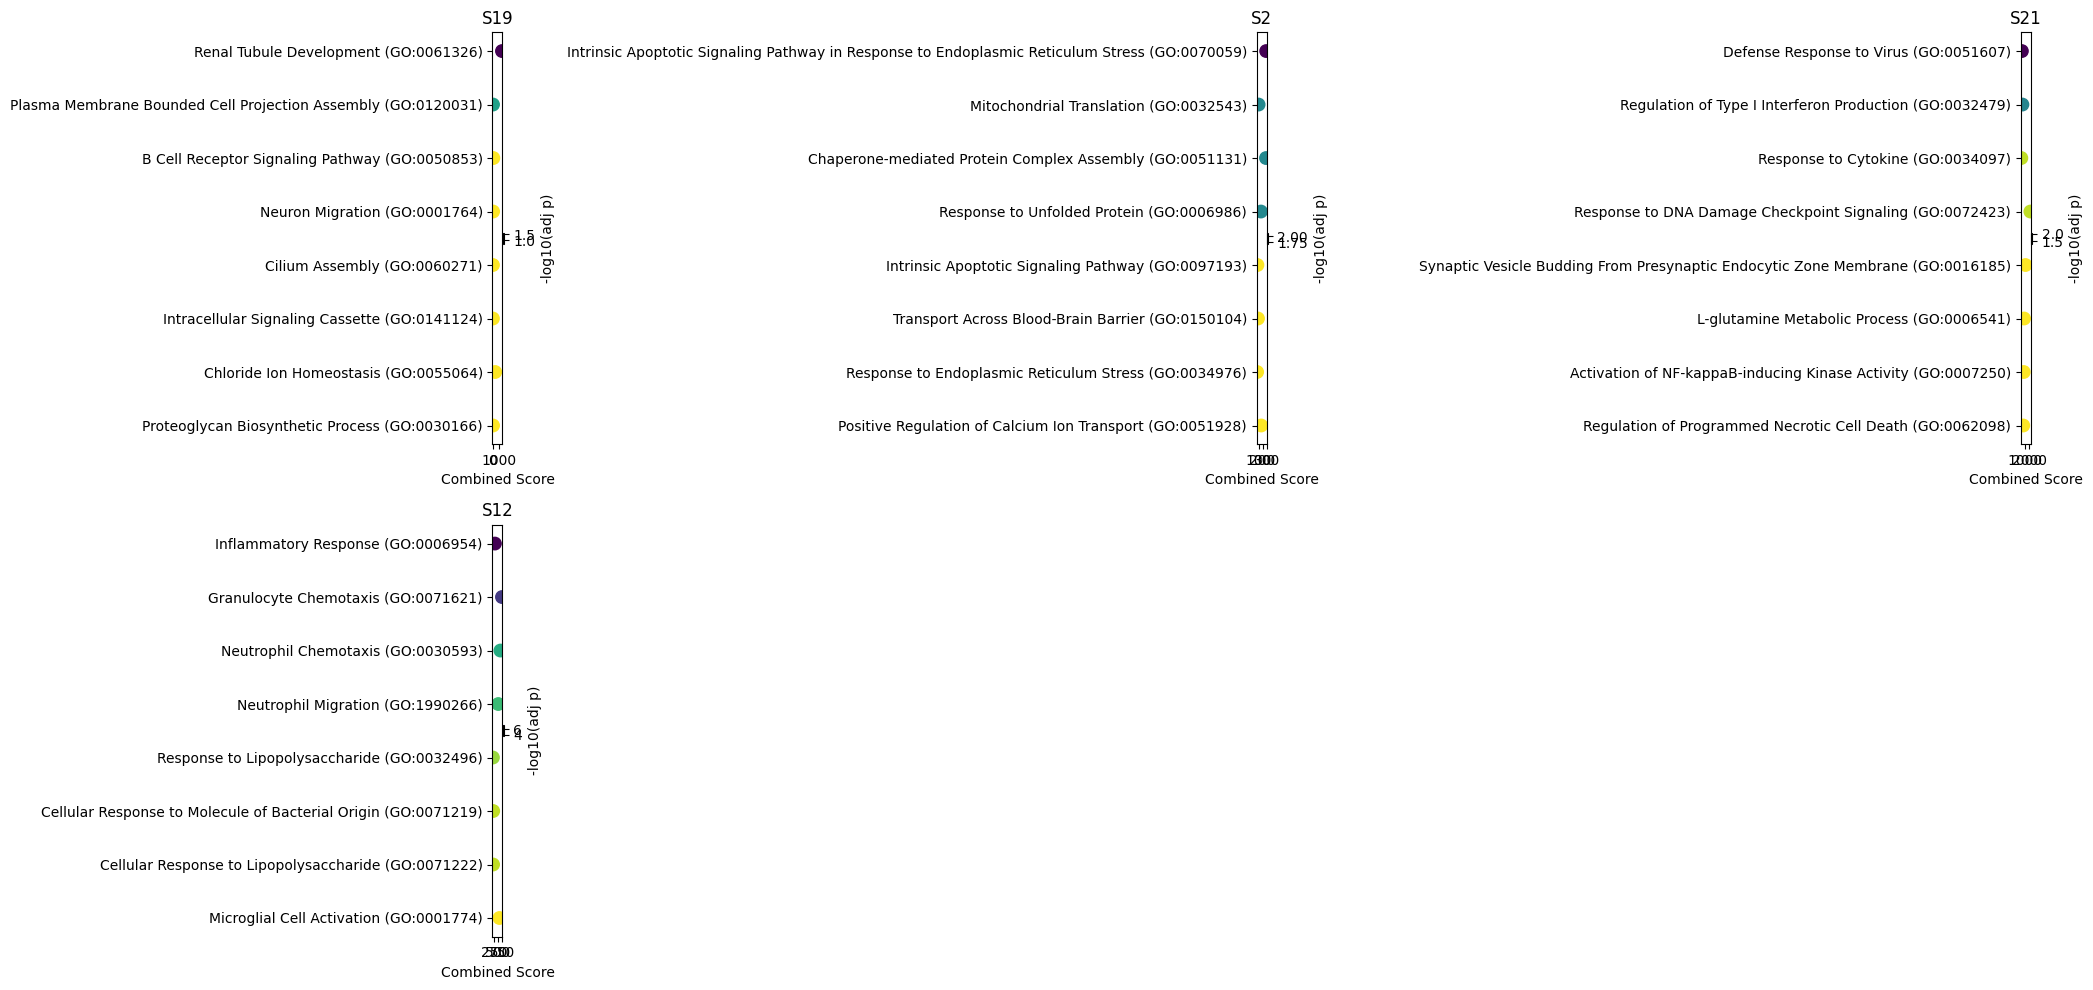

dict_keys(['Renal Tubule Development', 'Intrinsic Apoptotic Signaling Pathway in Response to Endoplasmic Reticulum Stress', 'Defense Response to Virus', 'Inflammatory Response'])


In [103]:
adata_hvg = adata_no_none[:, adata_no_none.var["highly_variable"]]

macrostates=["S19", "S2", "S21","S12"]
# DEG per macrostates
#sc.tl.rank_genes_groups(adata_hvg,groupby="macrostates",groups=list(macrostates),reference="rest", use_raw=False,method="wilcoxon")
sc.tl.rank_genes_groups(adata_hvg,groupby="macrostates",groups=["S19", "S2", "S21","S12"],reference="rest", use_raw=False,method="wilcoxon")


deg_lists_up = {}
deg_lists_down = {}

pval_thresh = 0.05
lfc_thresh = 1.0  # log fold change

for ct in macrostates:
    deg_df = sc.get.rank_genes_groups_df(adata_hvg, group=ct)
    up = deg_df[(deg_df["pvals_adj"] < pval_thresh) & (deg_df["logfoldchanges"] > lfc_thresh)]
    down = deg_df[(deg_df["pvals_adj"] < pval_thresh) & (deg_df["logfoldchanges"] < -lfc_thresh)]
    deg_lists_up[ct] = up["names"].tolist()
    deg_lists_down[ct] = down["names"].tolist()
    print(f"{ct}: {len(deg_lists_up[ct])} genes up, {len(deg_lists_down[ct])} genes down")

# Pathways enrichisment on up genes per macrostates
n = len(macrostates)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes = axes.flatten()

enrich_results = {}
top_terms_per_state = {}

for i, ct in enumerate(macrostates):
    print(f"Enrichment for {ct}")
    gene_list = deg_lists_up[ct]

    if len(gene_list) == 0:
        print(f"  No gene up regulated for {ct}, skip.")
        axes[i].axis("off")
        continue
    time.sleep(2)
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets="GO_Biological_Process_2026",
        organism="human",
        outdir=None
    )
    df = enr.results.copy()
    enrich_results[ct] = df

    if df.empty:
        print(f"  No enrichment result for {ct}, skip.")
        axes[i].axis("off")
        continue

    # Top pathways
    df_sorted = df.sort_values("Adjusted P-value")
    top2 = df_sorted.head(1)
    top_terms_per_state[ct] = top2["Term"].tolist()

    print(f"\nTop 2 pathways for {ct}:")
    for _, row in top2.iterrows():
        print(f"  - {row['Term']} (adj p={row['Adjusted P-value']:.2e})")

    df_plot = df.sort_values("Adjusted P-value").head(8).copy()
    df_plot["GeneRatio"] = df_plot["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))

    scp = axes[i].scatter(
        x=df_plot["Combined Score"],
        y=df_plot["Term"],
        c=-np.log10(df_plot["Adjusted P-value"]),
        s=80, cmap="viridis_r"
    )
    axes[i].set_title(ct)
    axes[i].set_xlabel("Combined Score")
    axes[i].set_ylabel("")
    axes[i].invert_yaxis()

    # Colorbar
    cbar = fig.colorbar(scp, ax=axes[i], fraction=0.05)
    cbar.set_label("-log10(adj p)", fontsize=10)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(wspace=0.6, hspace=0.4)
plt.tight_layout()
fig.savefig(f"{output_directory}/GO_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

def get_pathways_dict():
    url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2026"
    r = requests.get(url)
    pathways = {}
    for line in r.text.strip().split("\n"):
        parts = line.split("\t")
        if len(parts) > 2:
            pathways[parts[0]] = parts[2:]
    return pathways

pathway = get_pathways_dict()
pathways = {}
for ct, terms in top_terms_per_state.items():
    for term in terms:
        label = term.split(" (GO:")[0]
        if term in pathway:
            pathways[label] = pathway[term]
        else:
            print(f"WARNING : term '{term}' impossible to find in the database GO_Biological_Process_2026")

print(pathways.keys())

In [102]:
adata_hvg = adata_no_none[:, adata_no_none.var["highly_variable"]]


# DEG per macrostates
#sc.tl.rank_genes_groups(adata_hvg,groupby="macrostates",groups=list(macrostates),reference="rest", use_raw=False,method="wilcoxon")
sc.tl.rank_genes_groups(adata_hvg,groupby="macrostates",groups=["S19", "S2", "S21","S12"],reference="rest", use_raw=False,method="wilcoxon")


deg_lists_up = {}
deg_lists_down = {}

pval_thresh = 0.05
lfc_thresh = 1.0  # log fold change

for ct in macrostates:
    deg_df = sc.get.rank_genes_groups_df(adata_hvg, group=ct)
    up = deg_df[(deg_df["pvals_adj"] < pval_thresh) & (deg_df["logfoldchanges"] > lfc_thresh)]
    down = deg_df[(deg_df["pvals_adj"] < pval_thresh) & (deg_df["logfoldchanges"] < -lfc_thresh)]
    deg_lists_up[ct] = up["names"].tolist()
    deg_lists_down[ct] = down["names"].tolist()
    print(f"{ct}: {len(deg_lists_up[ct])} genes up, {len(deg_lists_down[ct])} genes down")

# Pathways enrichisment on up genes per macrostates
n = len(macrostates)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes = axes.flatten()

enrich_results = {}
top_terms_per_state = {}

for i, ct in enumerate(macrostates):
    print(f"Enrichment for {ct}")
    gene_list = deg_lists_up[ct]

    if len(gene_list) == 0:
        print(f"  No gene up regulated for {ct}, skip.")
        axes[i].axis("off")
        continue
    time.sleep(2)
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets="GO_Biological_Process_2026",
        organism="human",
        outdir=None
    )
    df = enr.results.copy()
    enrich_results[ct] = df

    if df.empty:
        print(f"  No enrichment result for {ct}, skip.")
        axes[i].axis("off")
        continue

    # Top pathways
    df_sorted = df.sort_values("Adjusted P-value")
    top2 = df_sorted.head(1)
    top_terms_per_state[ct] = top2["Term"].tolist()

    print(f"\nTop 2 pathways for {ct}:")
    for _, row in top2.iterrows():
        print(f"  - {row['Term']} (adj p={row['Adjusted P-value']:.2e})")

    df_plot = df.sort_values("Adjusted P-value").head(8).copy()
    df_plot["GeneRatio"] = df_plot["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))

    scp = axes[i].scatter(
        x=df_plot["Combined Score"],
        y=df_plot["Term"],
        c=-np.log10(df_plot["Adjusted P-value"]),
        s=80, cmap="viridis_r"
    )
    axes[i].set_title(ct)
    axes[i].set_xlabel("Combined Score")
    axes[i].set_ylabel("")
    axes[i].invert_yaxis()

    # Colorbar
    cbar = fig.colorbar(scp, ax=axes[i], fraction=0.05)
    cbar.set_label("-log10(adj p)", fontsize=10)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(wspace=0.6, hspace=0.4)
plt.tight_layout()
fig.savefig(f"{output_directory}/GO_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

def get_pathways_dict():
    url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2026"
    r = requests.get(url)
    pathways = {}
    for line in r.text.strip().split("\n"):
        parts = line.split("\t")
        if len(parts) > 2:
            pathways[parts[0]] = parts[2:]
    return pathways

pathway = get_pathways_dict()
pathways = {}
for ct, terms in top_terms_per_state.items():
    for term in terms:
        label = term.split(" (GO:")[0]
        if term in pathway:
            pathways[label] = pathway[term]
        else:
            print(f"WARNING : term '{term}' impossible to find in the database GO_Biological_Process_2026")

print(pathways.keys())

S2: 165 genes up, 102 genes down
S19: 232 genes up, 48 genes down
S21: 11 genes up, 44 genes down
S12: 87 genes up, 101 genes down


KeyError: "None of [Index(['S6'], dtype='object')] are in the [columns]"

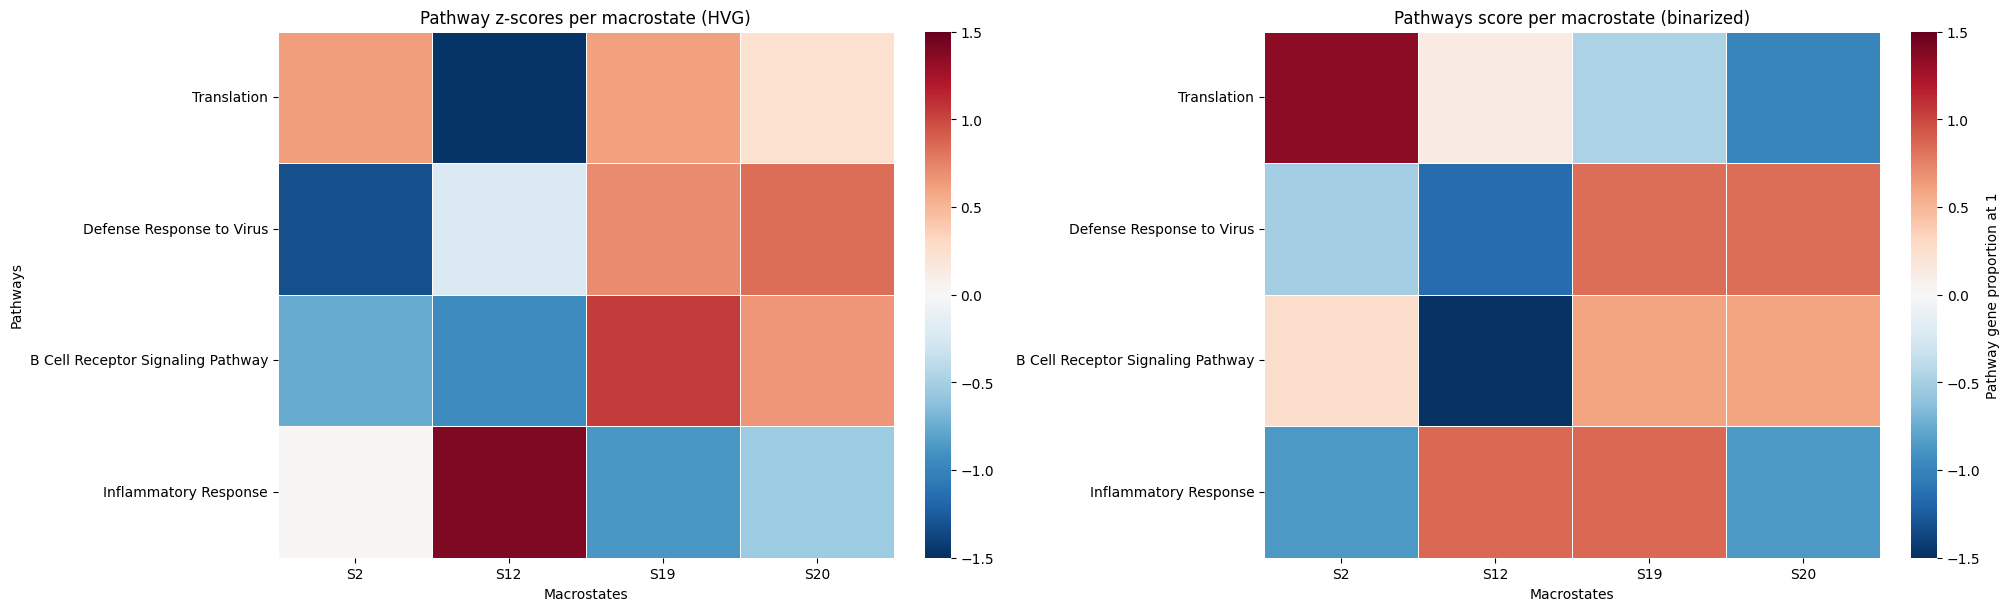

In [83]:
# Compute score for each cell for each pathway
for name, gene_list in pathways.items():
    gene_list_filtered = [g for g in gene_list if g in adata_no_none.var_names]
    if len(gene_list_filtered) == 0:
        print(f"No genes found for {name}")
        continue
    sc.tl.score_genes(adata_no_none, gene_list=gene_list_filtered, score_name=name)

scores = list(pathways.keys())
mean_scores = (
    adata_no_none.obs
    .groupby("macrostates")[scores]
    .mean())
mean_scores_z_all = mean_scores.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

binary_matrix = binarized_states.copy().fillna(np.nan)
binary_matrix = binary_matrix.apply(pd.to_numeric, errors="coerce")

scores = {}

for name, genes in pathways.items():
    # keep genes only present in binary_matrix
    genes_present = [g for g in genes if g in binary_matrix.columns]
    if len(genes_present) == 0:
        # pathway empthy
        scores[name] = pd.Series(np.nan, index=binary_matrix.index, dtype=float)
        continue

    mat = binary_matrix.loc[:, genes_present]

    num = (mat == 1).sum(axis=1)          # number of genes activated (=1) per macrostates
    den = mat.notna().sum(axis=1)         # number of 0 or 1, not NA
    score = num / den                     # if den > 0, else NaN
    #score = num / len(genes_present)

    scores[name] = score
    

scores_df = pd.DataFrame(scores)
order = sorted(
    [x for x in macrostates if x != "None"],
    key=lambda x: int(x.replace("S", ""))
)
#order = ["S2", "S6", "S12", "S19", "S20","S21"]
scores_df = scores_df.loc[order]
scores_df_z = scores_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
scores_df_z = scores_df_z.T
fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)

# 1. HEATMAP : HVG scores
sns.heatmap(
    mean_scores_z_all.T,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar=True,
    vmin=-1.5,
    vmax=1.5,
    yticklabels=True,
    ax=axes[0]
)

axes[0].set_title("Pathway z-scores per macrostate (HVG)", fontsize=12)
axes[0].set_xlabel("Macrostates")
axes[0].set_ylabel("Pathways")

# 2. HEATMAP : binarized
sns.heatmap(
    scores_df_z,
    cmap="RdBu_r",
    annot=False,
    linewidths=0.5,
    center=0,
    vmin=-1.5,
    vmax=1.5,
    cbar=True,
    cbar_kws={"label": "Pathway gene proportion at 1"},
    ax=axes[1]
)

axes[1].set_title("Pathways score per macrostate (binarized)", fontsize=12)
axes[1].set_xlabel("Macrostates")
axes[1].set_ylabel("")

# SAVE
plt.savefig(
    f"{output_directory}/pathways_heatmaps_side_by_side.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
# 1. SCORES HVG
for name, gene_list in pathways.items():
    gene_list_filtered = [g for g in gene_list if g in adata_no_none.var_names]
    if len(gene_list_filtered) == 0:
        print(f"No genes found for {name}")
        continue
    sc.tl.score_genes(adata_no_none, gene_list=gene_list_filtered, score_name=name)

pathway_names = list(pathways.keys())

mean_scores = (
    adata_no_none.obs
    .groupby("macrostates")[pathway_names]
    .mean()
)
mean_scores_z_all = mean_scores.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# 2. BINARISED SCORES  (proportion of 1 per macrostates)
binary_matrix = binarized_states.copy().fillna(np.nan)
binary_matrix = binary_matrix.apply(pd.to_numeric, errors="coerce")

order = sorted(
    [x for x in binary_matrix.index if x != "None"],
    key=lambda x: int(x.replace("S", ""))
)

prop_scores = {}
coverage_scores = {}

for name, genes in pathways.items():
    genes_present = [g for g in genes if g in binary_matrix.columns]

    if len(genes_present) == 0:
        prop_scores[name]     = pd.Series(np.nan, index=binary_matrix.index, dtype=float)
        coverage_scores[name] = pd.Series(0.0,    index=binary_matrix.index, dtype=float)
        continue

    mat = binary_matrix.loc[:, genes_present]

    num = (mat == 1).sum(axis=1)           # nb of genes at 1
    den = mat.notna().sum(axis=1)          # nb of genes not-NA

    prop_scores[name]     = num / den.replace(0, np.nan)
    coverage_scores[name] = den / len(genes_present)  # fraction du pathway couverte

prop_df     = pd.DataFrame(prop_scores).loc[order]
coverage_df = pd.DataFrame(coverage_scores).loc[order]

# Z-score (pathways x states)
prop_df_z = prop_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0).T

# 3. LOG2 FOLD-CHANGE vs global mean
mean_global = prop_df.mean(axis=0)  
lfc = np.log2((prop_df + 1e-3) / (mean_global + 1e-3))
lfc_T = lfc.T 

# 4. VISUALIZATION: 2 heatmaps side by side
hvg_z_T = mean_scores_z_all.T

shared_states   = [s for s in order if s in hvg_z_T.columns]
shared_pathways = [p for p in pathway_names if p in hvg_z_T.index]

hvg_z_T   = hvg_z_T.loc[shared_pathways, shared_states]
lfc_T     = lfc_T.loc[shared_pathways, shared_states]
low_cov_mask = low_cov_mask.loc[shared_pathways, shared_states]

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, max(6, len(shared_pathways) * 0.4 + 2)),
    constrained_layout=True
)

CMAP = "RdBu_r"
VABS = 1.5
KW_CBAR = dict(shrink=0.6)

# Heatmap 1: HVG z-score 
sns.heatmap(
    hvg_z_T, ax=axes[0],
    cmap=CMAP, center=0, vmin=-VABS, vmax=VABS,
    linewidths=0.5, cbar=True, cbar_kws=KW_CBAR,
    yticklabels=True, xticklabels=True
)
axes[0].set_title("HVG z-score\n(continuous expression)", fontsize=11)
axes[0].set_xlabel("Macrostates")
axes[0].set_ylabel("Pathways")

# Heatmap 3: Log2 FC + low coverage mask 
sns.heatmap(
    lfc_T, ax=axes[1],
    cmap=CMAP, center=0, vmin=-2, vmax=2,
    linewidths=0.5, cbar=True, cbar_kws=KW_CBAR,
    mask=low_cov_mask,
    yticklabels=True, xticklabels=True
)
sns.heatmap(
    lfc_T, ax=axes[1],
    cmap=["#cccccc"], alpha=0.6,
    mask=~low_cov_mask,
    cbar=False, linewidths=0.5,
    yticklabels=True, xticklabels=True
)
axes[1].set_title("Log2 FC vs global mean\n(gray if coverage < 20%)", fontsize=11)
axes[1].set_xlabel("Macrostates")
axes[1].set_ylabel("Pathways")

plt.suptitle("Binarization assessment — comparison of metrics", fontsize=13, y=1.02)

plt.savefig(
    f"{output_directory}/pathways_binarization_evaluation_1_3.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

NameError: name 'low_cov_mask' is not defined

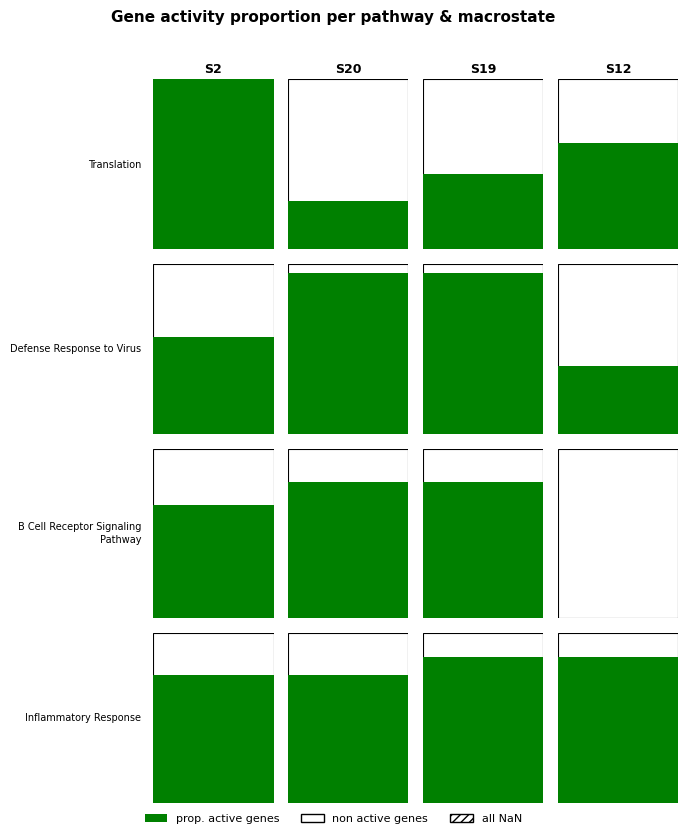

In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import textwrap

def plot_pathway_proportions(binarized_states, pathways, figsize_scale=(1.8, 2.0)):
    """
    binarized_states : DataFrame binaire (0/1/NaN)
                       index = macrostates (ex: S2, S20, ...)
                       colonnes = gènes
    pathways         : dict {nom_pathway: [liste de gènes]}
    """
    macrostates = list(binarized_states.index)
    n_states    = len(macrostates)
    n_pathways  = len(pathways)

    fig, axes = plt.subplots(
        n_pathways, n_states,
        figsize=(n_states * figsize_scale[0], n_pathways * figsize_scale[1]),
        squeeze=False
    )

    for row, (pw_name, genes) in enumerate(pathways.items()):
        for col, state in enumerate(macrostates):
            ax = axes[row, col]
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis("off")

            # Pathways genes prsent in the matrix
            pw_genes = [g for g in genes if g in binarized_states.columns]

            if not pw_genes:
                ax.add_patch(patches.Rectangle(
                    (0, 0), 1, 1, transform=ax.transAxes,
                    facecolor="lightgray", edgecolor="green", linewidth=0.8
                ))
                ax.text(0.5, 0.5, "no genes", ha="center", va="center",
                        color="gray", fontsize=7, transform=ax.transAxes)
            else:
                values = binarized_states.loc[state, pw_genes]
                valid  = values.dropna()

                # White 
                ax.add_patch(patches.Rectangle(
                    (0, 0), 1, 1, transform=ax.transAxes,
                    facecolor="white", edgecolor="black", linewidth=0.8
                ))

                if len(valid) == 0:
                    # Nan
                    ax.add_patch(patches.Rectangle(
                        (0, 0), 1, 1, transform=ax.transAxes,
                        facecolor="none", edgecolor="black", linewidth=0.8,
                        hatch="////"
                    ))
                else:
                    proportion = valid.sum() / len(valid)
                    if proportion > 0:
                        ax.add_patch(patches.Rectangle(
                            (0, 0), 1, proportion, transform=ax.transAxes,
                            facecolor="green", edgecolor="none"
                        ))

            # Header macrostates
            if row == 0:
                ax.set_title(state, fontsize=9, pad=5, fontweight="bold")

            # Label pathway
            if col == 0:
                wrapped = "\n".join(textwrap.wrap(pw_name, width=28))
                ax.text(-0.1, 0.5, wrapped,fontsize=7, rotation=0,va="center", ha="right",transform=ax.transAxes,linespacing=1.4)

    fig.suptitle("Gene activity proportion per pathway & macrostate",
                 fontsize=11, y=1.01, fontweight="bold")

    # Legend
    legend_elements = [
        patches.Patch(facecolor="green", label="prop. active genes"),
        patches.Patch(facecolor="white", edgecolor="black", label="non active genes"),
        patches.Patch(facecolor="none",  edgecolor="black", hatch="////", label="all NaN"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.02),
               frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(left=0.25)
    plt.savefig("pathway_proportions.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_pathway_proportions(binarized_states, pathways)